# 25 — Atomic cells: rights profiles across three periods

Operationalises the **full-intersection / atomic-cell** framework. Every person belongs to exactly one cell defined by the tuple

$$G_{(c_{\text{sex}}, c_{\text{age}}, c_{\text{ownership}}, c_{\text{ancestry}}, c_{\text{residence}}, c_{\text{wealth}})}$$

and rights are observed empirically by aggregating rules that touch the cell.

### Source of the criterion vectors

This notebook uses the **text-grounded** criterion vectors (one per rule) from `data/clean/final/rule_criterion_vectors.tsv`. The classifier (`scripts/classifiers/classify_rule_criteria_from_text.py`) reads the verbatim of each rule and marks each axis as `stated` (directly named by the verbatim), `implied` (lexically presupposed by the emic word the verbatim uses, e.g. *wife* → female), or `unspecified` (the text does not constrain this axis).

This is the methodological correction to the earlier label-grounded approach, where the criterion vector for a group label like `Citizens` was inferred from the LLM's background knowledge of Athenian law. That older artifact (`data/clean/final/group_criterion_vectors.tsv`) is kept for comparison in §8.

Three periods:

| Code | Span | Rough scope |
|---|---|---|
| **P1** | Classical Greek (500–360 BCE) | Athenian democracy, Solonic, Cleisthenic |
| **P2** | Late Classical (354–165 BCE) | Demosthenes / Aristotle era, into Hellenistic |
| **P3** | Hellenistic & Roman (165 BCE – 205 CE) | Polybius onward — Greek polis under Rome |

Three things this notebook produces:

1. The atomic-cell rights profile $\rho(G)$ in each period.
2. **Emergent intersectional rights** — rights that exist at an atomic cell but disappear if you relax *any* single criterion.
3. Cross-period evolution — cells that gain/lose specific rights between P1, P2, P3.

And one bonus diagnostic in §8: where text-grounded vs label-grounded vectors disagree on each axis.

## The six criteria and the values they can take

Each atomic cell is a tuple over six **rights-independent** criteria. Every criterion is a fact about persons that can be stated without referring to voting, court access, office-holding, or any other legal/rights category — so the same cell picks out the same humans even in a counterfactual society with different laws.

| Criterion | Values |
|---|---|
| `c_sex` | `Male` / `Female` / `*` |
| `c_age` | `Adult` / `Minor` / `Elder` / `*` |
| `c_ownership_status` | `Free` / `Enslaved` / `Freed` / `*` |
| `c_ancestry` | `Native` / `Foreign` / `Mixed` / `*` |
| `c_residence` | `Resident` / `Non resident` / `*` |
| `c_wealth` | `High` / `Middle` / `Low` / `*` |

**Reading a cell signature.** Cell codes are six tokens separated by `/`, in the fixed axis order **(sex, age, ownership, ancestry, residence, wealth)**. The token is the criterion value with the first letter capitalised. `*` means "unconstrained on this axis" (covering both "applies to all values" and "text doesn't say").

Examples:

- `Male/Adult/Free/Native/Resident/*` — the *politēs* / *civis* cell.
- `*/*/Enslaved/*/Resident/Low` — the *doulos* cell.
- `Female/Adult/Free/Native/Resident/*` — Athenian wives / *gynaikes* of citizen households.
- `Male/Adult/Free/Native/Resident/High` — the wealthy Solonic top class (*pentakosiomedimnoi*).

**Two metadata fields** travel alongside the criterion vector and are *not* part of the cell key:

- `requires_rights_definition` (`True` / `False`) — flagged when a group exists *only* as a legal/office category (`Magistrates`, `Voters`, `Archons`). These rows are filtered out below because their existence already presupposes the rights system.
- `emic_label` / `emic_label_in_text` — the native-language term (*politēs*, *metoikos*, *doulos*, *eupatridēs*, *pentakosiomedimnoi*, …). **A label observed on the cell, not its definition.**

The full prompt for each pipeline is in `scripts/classifiers/prompt/`.

## Worked examples — how each group was associated with its criterion values

The classifier received **only** the group label, the polity, and the period — never the rule, resource, or directionality — so rights could not leak into the criterion vector. Below are ten real rows from `data/clean/final/group_criterion_vectors.tsv`, each showing how an emic group label was decomposed.

| Group label (emic) | Polity | Sex | Age | Ownership | Ancestry | Residence | Wealth | Occupation | rights-defined? | Emic label inferred | Cell signature |
|---|---|---|---|---|---|---|---|---|---|---|---|
| **Citizens** | Classical Athens | male | adult | free | native | resident | any | unspecified | — | *politēs* | `Male/Adult/Free/Native/Resident/*` |
| **Slaves** | Classical Athens | any | any | enslaved | any | resident | low | any | — | *douloi* | `*/*/Enslaved/*/Resident/Low` |
| **Metics** | Classical Athens | any | adult | free | foreign | resident | any | any | — | *metoikos* | `*/Adult/Free/Foreign/Resident/*` |
| **Naturalized citizens** | Classical Athens | male | adult | free | foreign | resident | any | any | ✓ rights-defined | *poiētos politēs* | `Male/Adult/Free/Foreign/Resident/*` |
| **Women** | Classical Athens | female | any | any | unspecified | resident | any | unspecified | — | *gynaikes* | `Female/*/*/*/Resident/*` |
| **Minors** | Classical Athens | any | minor | free | native | resident | unspecified | none | — | *pais* | `*/Minor/Free/Native/Resident/*` |
| **The wealthy** | Classical Athens | any | adult | free | unspecified | resident | high | any | — | *plousioi* | `*/Adult/Free/*/Resident/High` |
| **The poor** | Classical Athens | any | any | free | unspecified | resident | low | any | — | *penētes* | `*/*/Free/*/Resident/Low` |
| **Magistrates** | Classical Athens | male | adult | free | native | resident | any | magistrate | ✓ rights-defined | *archōn* | `Male/Adult/Free/Native/Resident/*` |

**Reading these rows.**

- **`Citizens` in Classical Athens** decomposes into *Male / Adult / Free / Native / Resident / Any wealth* — the criterion vector for the cell Athenians called *politēs*. Nothing about voting, court access, or office-holding appears in the vector — those are observed empirically later.
- **`Naturalized citizens`** keeps ancestry = `Foreign` even though the legal regime granted them citizenship. The Kripkean rigid-designator test: the genealogical fact persists across legal changes. The shift in their legal status will show up as an empirical fact in $\rho(G)$, not in the cell key.
- **`Slaves`** is encoded as ownership = `Enslaved` and wealth = `Low` but **everything else collapses to `*`** — slavery is constitutive of the cell, not a regulative right; the slave can be of any sex, age, or ancestry.
- **`Magistrates`** is flagged `requires_rights_definition = True`. The underlying eligible population (Male / Adult / Free / Native / Resident) is filled in, but the row is *excluded* from the rights-profile analysis because being a magistrate already presupposes the rights system we are trying to measure.
- **`The wealthy`** and **`The poor`** differ only on wealth (`High` vs `Low`); every other axis is `*` because the emic label only constrains the wealth dimension. Same logic for **`Women`** and **`Minors`**, each pinning a single axis.
- **`Foreigners` in the Roman Empire** vs **`Metics` in Classical Athens**: same etic cell signature `*/Adult/Free/Foreign/Resident/*` but different emic labels.

The full prompt that produced these vectors is in `scripts/classifiers/prompt/prompt_group_criteria.md`.

In [1]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

ROOT = Path('..').resolve()
SRC = ROOT / 'data/clean/final/rules_with_criteria.tsv'
print('Loading from', SRC.relative_to(ROOT))

Loading from data/clean/final/rules_with_criteria.tsv


## 1. Load, periodize, and filter

Join the original rules table with the text-grounded criterion vectors (one per rule). Build the atomic-cell signature from the text-grounded axes. Drop rules already flagged as tautological.

In [2]:
RULES_SRC = ROOT / 'data/rules_dataset_april_2026.tsv'
CRIT_SRC  = ROOT / 'data/clean/final/rule_criterion_vectors.tsv'

rules = pd.read_csv(RULES_SRC, sep='\t')
crit  = pd.read_csv(CRIT_SRC,  sep='\t')
df = rules.merge(crit, on='rule_id', how='left')

AXES = ['c_sex','c_age','c_ownership_status','c_ancestry','c_residence','c_wealth']

# Human-readable cell signatures: "Male/Adult/Free/Native/Resident/*"
def _token(v):
    if pd.isna(v): return 'Unknown'
    v = str(v)
    if v in ('any','unspecified'): return '*'
    return v.replace('_', ' ').capitalize()

def cell_signature(row):
    return '/'.join(_token(row[c]) for c in AXES)

df['cell_sig'] = df.apply(cell_signature, axis=1)

PERIOD_MAP = {
    'Classical (500\u2013360 BCE)':                       'P1: Classical Greek (500\u2013360 BCE)',
    'Late Classical (354\u2013165 BCE)':                  'P2: Late Classical (354\u2013165 BCE)',
    'Hellenistic & Early Roman (165 BCE \u2013 105 CE)':  'P3: Hellenistic & Roman (165 BCE \u2013 205 CE)',
    'High Roman Empire (135\u2013205 CE)':                'P3: Hellenistic & Roman (165 BCE \u2013 205 CE)',
}
df['period3'] = df['period'].map(PERIOD_MAP)

F = df[(df['tautology'] != 1) & df['period3'].notna()].copy()

PERIODS = ['P1: Classical Greek (500\u2013360 BCE)',
           'P2: Late Classical (354\u2013165 BCE)',
           'P3: Hellenistic & Roman (165 BCE \u2013 205 CE)']

summary = (
    F.groupby('period3')
     .agg(n_rules=('rule_id', 'size'),
          n_cells=('cell_sig', 'nunique'),
          n_polities=('rule_polity', 'nunique'))
     .reindex(PERIODS)
)
print('Loaded text-grounded criterion vectors:', len(crit), 'rules')
print('Period summary:')
summary

Loaded text-grounded criterion vectors: 1011 rules
Period summary:


,n_rules,n_cells,n_polities
period3,,,
P1: Classical Greek (500–360 BCE),283,47,16
P2: Late Classical (354–165 BCE),397,68,39
P3: Hellenistic & Roman (165 BCE – 205 CE),240,57,47


### Evidence levels per axis

Each axis in the text-grounded vector carries an `_evidence` flag. The distribution shows how often the verbatim *actually* constrains each axis — most rules leave several axes `unspecified` because the source text does not state them. This is the honest answer: the earlier label-grounded vectors filled most axes in from background knowledge.

In [3]:
ev_rows = []
for ax in AXES:
    ec = F[f'{ax}_evidence'].value_counts()
    ev_rows.append({
        'axis': ax,
        'stated': int(ec.get('stated', 0)),
        'implied': int(ec.get('implied', 0)),
        'unspecified': int(ec.get('unspecified', 0)),
    })
ev_df = pd.DataFrame(ev_rows)
ev_df['pct_constrained'] = ((ev_df['stated'] + ev_df['implied']) * 100 / len(F)).round(1)
ev_df

,axis,stated,implied,unspecified,pct_constrained
0,c_sex,84,199,637,30.8
1,c_age,52,114,754,18.0
2,c_ownership_status,54,312,554,39.8
3,c_ancestry,49,112,759,17.5
4,c_residence,34,57,829,9.9
5,c_wealth,117,65,738,19.8


## 2. The atomic cells

Each rule lives in exactly one cell. The signature is a compact 6-letter code over the axes
(sex, age, ownership, ancestry, residence, wealth). `*` means "any / unspecified" on that axis.

Below: the top cells in each period and the emic labels Athenian/Roman authors layered on them.

In [4]:
AXES = ['c_sex','c_age','c_ownership_status','c_ancestry','c_residence','c_wealth']

def top_cells(period: str, k: int = 12) -> pd.DataFrame:
    s = F[F['period3'] == period]
    by = (
        s.groupby('cell_sig')
         .agg(n_rules=('rule_id','size'),
              emic_in_text=('emic_label_in_text',
                            lambda x: '; '.join(sorted({v for v in x if isinstance(v, str)}))[:90]))
         .reset_index()
         .sort_values('n_rules', ascending=False)
         .head(k)
    )
    return by

for p in PERIODS:
    print('=' * 90)
    print(p)
    print('=' * 90)
    display(top_cells(p))

P1: Classical Greek (500–360 BCE)


,cell_sig,n_rules,emic_in_text
0,*/*/*/*/*/*,79,Atreus; Gymnasiarch; I; Lycurgus / Solon; Merchants; Mr. Informer; Peiraeus ...
13,*/*/Free/*/*/*,23,accused; all who deserted on the field; all who enjoy civic rights; all who ...
32,Male/*/*/*/*/*,22,He; a man; defendant; demesmen; descendants of males; friends; gentlemen of ...
1,*/*/*/*/*/High,13,Choregi; Protagoras; great house; kindred; lender; private citizens or monar...
11,*/*/Enslaved/*/*/*,13,Cario; domestics and servants; he who was born and bred in your house; his l...
36,Male/*/Free/*/*/*,13,Senators; a man; acknowledged citizens; adopted son; free man; legitimate so...
17,*/*/Free/Native/*/*,11,Athenian citizen; Athenian people; citizen; citizens; citizens by birth; sol...
7,*/*/*/Foreign/*/*,7,Scythian; Scythians; alien; allies; foreigners; prisoners of war; stranger i...
33,Male/*/*/*/*/High,7,Choregus; he; men of property; son; the twelve hundred who pay the war-taxes...
21,*/Minor/*/*/*/*,7,attendant; children; infant; offspring; people ... at too early an age; pupi...


P2: Late Classical (354–165 BCE)


,cell_sig,n_rules,emic_in_text
0,*/*/*/*/*/*,91,"Any one; Athenian; Eupatridae, Agroeci, and Demiurgi; Greeks and barbarians;..."
1,*/*/*/*/*/High,30,Five-hundred-bushel class and the Teamsters and a third property-class calle...
15,*/*/Free/*/*/*,27,all men [who] possess freedom; all the citizens; any citizen; anyone; citize...
2,*/*/*/*/*/Low,26,Thetes; common people; defaulter; hired laborer; infirm paupers; mechanics a...
46,Male/*/*/*/*/*,23,No man; a man; any man; board of inspectors; he; he who wishes; him; man; ma...
12,*/*/Enslaved/*/*/*,22,person ransomed; serf class; slave; slave belonging to the city; slaves; sla...
23,*/*/Free/Native/*/*,17,Athenian; Athenian families; Athenians; child of citizens on both sides; chi...
9,*/*/*/Native/*/*,10,Athenians; ancestors; candidate / nine Archons; certain clans; distinguished...
58,Male/Adult/Free/*/*/*,9,brave men; citizens’ list; envoy; man; men who enter public life; son
41,Female/*/Free/*/*/*,9,daughter; daughters; free woman; heiresses; wife; women / wife / daughter


P3: Hellenistic & Roman (165 BCE – 205 CE)


,cell_sig,n_rules,emic_in_text
0,*/*/*/*/*/*,59,"Aratus; Gentlemen; Greek cities; Hieronymuses; High Priest, ministers; High ..."
12,*/*/Free/*/*/*,16,Roman citizenslfip; a people; administrators of all the provinces; citizens;...
38,Male/*/*/*/*/*,14,Galles; captives man for man; citizens; consul; dancer; dictator; general; m...
10,*/*/Enslaved/*/*/*,12,"Helots; servants; slave; slavery, bondage; slaves"
48,Male/Adult/Free/*/*/*,9,Professor; garb of a man; king; married sons; philosopher; pontifex maximus;...
34,Female/Adult/Free/*/*/*,8,her; married woman; wife; women; women who have lost their husbands; wyf
1,*/*/*/*/*/High,7,Pentacosiomedimni; choregoi; luxurious livers; men from great houses; rich m...
19,*/*/Free/Native/*/*,7,Corinthians; Spartans; citizen; citizens; citizens ... from the condition of...
28,Female/*/*/*/*/*,7,Women; flutegirl; wives and daughters; woman; women; wommen
5,*/*/*/Foreign/*/*,7,Corinthian; Corinthian by birth; Greek city-states; The Foreign Physician; f...


## 3. The atomic-cell rights profile $\rho(G)$ per period

For each (period, cell, resource), tally MORE / LESS counts. The `net` column is `MORE − LESS`:
positive means the cell tends to *hold* the right, negative means it tends to *lack* it.
Mixed signs are themselves interesting — they flag contested rights or sub-period variation within the same cell.

In [5]:
def rho(period: str) -> pd.DataFrame:
    s = F[F['period3'] == period]
    by = (
        s.groupby(['cell_sig','resource_meta','directionality'])
         .size().reset_index(name='n')
    )
    pv = by.pivot_table(index=['cell_sig','resource_meta'],
                        columns='directionality', values='n', fill_value=0).reset_index()
    pv.columns.name = None
    for c in ('MORE','LESS'):
        if c not in pv.columns:
            pv[c] = 0
    pv['net'] = pv['MORE'] - pv['LESS']
    pv['n_total'] = pv['MORE'] + pv['LESS']
    return pv.sort_values(['cell_sig','n_total'], ascending=[True, False])

rho_by_period = {p: rho(p) for p in PERIODS}
for p in PERIODS:
    r = rho_by_period[p]
    print(p, '→', r['cell_sig'].nunique(), 'cells,', r['resource_meta'].nunique(),
          'resources,', len(r), '(cell,resource) rows')

P1: Classical Greek (500–360 BCE) → 47 cells, 37 resources, 178 (cell,resource) rows
P2: Late Classical (354–165 BCE) → 68 cells, 37 resources, 235 (cell,resource) rows
P3: Hellenistic & Roman (165 BCE – 205 CE) → 57 cells, 39 resources, 178 (cell,resource) rows


In [6]:
for p in PERIODS:
    r = rho_by_period[p]
    r2 = r.assign(abs_net=r['net'].abs()).sort_values('abs_net', ascending=False).head(15)
    print('\n' + '=' * 90)
    print(p)
    print('=' * 90)
    display(r2[['cell_sig','resource_meta','MORE','LESS','net']])


P1: Classical Greek (500–360 BCE)


,cell_sig,resource_meta,MORE,LESS,net
13,*/*/*/*/*/*,Right to a legal trial,12.0,0.0,12.0
2,*/*/*/*/*/*,Eligibility for public office,8.0,0.0,8.0
67,*/*/Enslaved/*/*/*,Protection from corporal punishment,0.0,6.0,-6.0
156,Male/*/Free/*/*/*,Right to inherit property,6.0,0.0,6.0
24,*/*/*/*/*/*,Right to retain own earnings,4.0,0.0,4.0
79,*/*/Free/*/*/*,Right to a legal trial,4.0,0.0,4.0
6,*/*/*/*/*/*,Exemption from military service,3.0,0.0,3.0
29,*/*/*/*/*/High,Exemption from compulsory public financing,0.0,3.0,-3.0
97,*/*/Free/Native/*/*,Right to citizenship,0.0,2.0,-2.0
50,*/*/*/Foreign/*/*,Eligibility for public office,2.0,0.0,2.0



P2: Late Classical (354–165 BCE)


,cell_sig,resource_meta,MORE,LESS,net
14,*/*/*/*/*/*,Right to a legal trial,12.0,2.0,10.0
92,*/*/Free/*/*/*,Eligibility for public office,6.0,0.0,6.0
80,*/*/Enslaved/*/*/*,Protection from corporal punishment,0.0,6.0,-6.0
31,*/*/*/*/*/High,Exemption from taxes,0.0,5.0,-5.0
190,Male/*/*/*/*/*,Right to address the assembly,1.0,5.0,-4.0
102,*/*/Free/*/*/*,Right to remuneration for office,4.0,0.0,4.0
47,*/*/*/*/*/Low,Right to remuneration for office,4.0,0.0,4.0
78,*/*/Enslaved/*/*/*,Political power,0.0,3.0,-3.0
17,*/*/*/*/*/*,Right to citizenship,0.0,3.0,-3.0
29,*/*/*/*/*/High,Exemption from compulsory public financing,0.0,3.0,-3.0



P3: Hellenistic & Roman (165 BCE – 205 CE)


,cell_sig,resource_meta,MORE,LESS,net
0,*/*/*/*/*/*,Access to public honors,5.0,0.0,5.0
11,*/*/*/*/*/*,Right to a legal trial,4.0,0.0,4.0
169,Male/Adult/Free/Native/*/*,Eligibility for public office,4.0,0.0,4.0
3,*/*/*/*/*/*,Eligibility for public office,5.0,2.0,3.0
71,*/*/Free/*/*/*,Right to citizenship,3.0,0.0,3.0
138,Male/*/*/*/*/*,Political power,3.0,0.0,3.0
126,Female/Adult/Free/*/*/*,Right to bodily autonomy,0.0,3.0,-3.0
12,*/*/*/*/*/*,Right to bear arms,0.0,3.0,-3.0
5,*/*/*/*/*/*,Political power,5.0,2.0,3.0
91,*/*/Free/Native/*/*,Eligibility for public office,3.0,0.0,3.0


## 4. Emergent intersectional rights

An attached right $r$ is **emergent at the intersection** when removing *any* single criterion from the cell's tuple expands the group to one that does not (uniformly) have $r$.

Operationally, for each cell $C$ and each net-positive right $r \in \rho(C)$:

1. For every axis $i$, compute the *axis-relaxation* — the set of cells in the same period that match $C$ on all axes except $i$.
2. Look up whether any of those neighbour cells also has $r$ with $\text{net} \ge 1$.
3. If **no** axis-relaxation gives $r$, the right is fully intersectional.
4. If $k < K$ axes still give $r$, we say the right is "essential on $K - k$ axes".

The most striking signature is `essential_axes = 6` — the right is exactly at $C$ and not at any one-axis broader group.

In [7]:
def detect_intersectional(period: str, min_n: int = 1) -> pd.DataFrame:
    """Per-period emergent-rights detector.

    Returns one row per (cell, resource) where the right is net-positive at the cell.
    `essential_axes` counts axes whose value is necessary for the right to hold; if
    equal to len(AXES), the right is fully intersectional.
    """
    s = F[F['period3'] == period].copy()
    # Per-cell direction count
    cell_rights = (s.groupby(['cell_sig'] + AXES + ['resource_meta','directionality'])
                   .size().unstack('directionality', fill_value=0).reset_index())
    for c in ('MORE','LESS'):
        if c not in cell_rights.columns:
            cell_rights[c] = 0
    cell_rights['net'] = cell_rights['MORE'] - cell_rights['LESS']

    positives = cell_rights[(cell_rights['net'] >= 1) & ((cell_rights['MORE'] + cell_rights['LESS']) >= min_n)].copy()

    # Index of (axes-tuple) → resource → net for fast neighbour lookup
    by_axes = cell_rights.set_index(AXES + ['resource_meta'])['net']

    rows = []
    for _, r in positives.iterrows():
        axis_vals = tuple(r[a] for a in AXES)
        resource = r['resource_meta']
        essential = []
        for i, axis in enumerate(AXES):
            # Cells that agree on all axes except `axis` and also carry the same resource
            # We look up by selecting all rows matching the 5-axis pattern.
            keep = [a for j, a in enumerate(AXES) if j != i]
            mask_ = (cell_rights[resource_col := 'resource_meta'] == resource)
            for a in keep:
                mask_ &= (cell_rights[a] == r[a])
            neighbours = cell_rights[mask_ & (cell_rights[axis] != r[axis])]
            has_right = (neighbours['net'] >= 1).any() if len(neighbours) else False
            essential.append(0 if has_right else 1)
        rows.append({
            'cell_sig': r['cell_sig'],
            'resource_meta': resource,
            'MORE': int(r['MORE']),
            'LESS': int(r['LESS']),
            'net': int(r['net']),
            'essential_axes': int(sum(essential)),
            'essential_axes_list': ', '.join(a for a, e in zip(AXES, essential) if e),
            **{a: r[a] for a in AXES},
        })
    out = pd.DataFrame(rows).sort_values(['essential_axes','net'], ascending=[False, False])
    return out

intersect_by_period = {p: detect_intersectional(p) for p in PERIODS}
for p in PERIODS:
    r = intersect_by_period[p]
    print(p, '→', len(r), 'positive (cell,right) pairs |',
          'fully intersectional (essential_axes==6):',
          int((r['essential_axes']==6).sum()))

P1: Classical Greek (500–360 BCE) → 103 positive (cell,right) pairs | fully intersectional (essential_axes==6): 40
P2: Late Classical (354–165 BCE) → 118 positive (cell,right) pairs | fully intersectional (essential_axes==6): 53
P3: Hellenistic & Roman (165 BCE – 205 CE) → 89 positive (cell,right) pairs | fully intersectional (essential_axes==6): 44


In [8]:
# Most-intersectional rights per period (essential_axes = 6 or 5)
for p in PERIODS:
    print('\n' + '=' * 90)
    print(p, '— emergent intersectional rights (essential_axes \u2265 5)')
    print('=' * 90)
    r = intersect_by_period[p]
    show = r[r['essential_axes'] >= 5].head(15)
    if show.empty:
        print('  (none — every right at this period inherits from at least one broader margin)')
    else:
        display(show[['cell_sig','resource_meta','MORE','LESS','net','essential_axes','essential_axes_list']])


P1: Classical Greek (500–360 BCE) — emergent intersectional rights (essential_axes ≥ 5)


,cell_sig,resource_meta,MORE,LESS,net,essential_axes,essential_axes_list
7,*/*/*/*/*/*,Exemption from military service,3,0,3,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
67,Female/Adult/Free/*/*/*,Right to retain property,2,0,2,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
89,Male/*/Free/*/*/*,Right to adopt,2,0,2,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
102,Male/Minor/Free/*/*/*,Right to citizenship,2,0,2,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
0,*/*/*/*/*/*,Right to address the assembly,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
1,*/*/*/*/*/*,Protection from corporal punishment,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
11,*/*/*/*/*/*,Right to bodily autonomy,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
12,*/*/*/*/*/*,Right to free speech,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
20,*/*/*/*/*/High,Right to citizenship,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
21,*/*/*/*/*/High,Right to valid professional opinion,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"



P2: Late Classical (354–165 BCE) — emergent intersectional rights (essential_axes ≥ 5)


,cell_sig,resource_meta,MORE,LESS,net,essential_axes,essential_axes_list
71,*/*/Free/Native/Resident/*,Right to bear arms,2,0,2,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
77,*/Minor/*/*/*/*,Access to public honors,2,0,2,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
80,*/Minor/*/*/*/*,Protection from legal prosecution,2,0,2,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
0,*/*/*/*/*/*,Protection from corporal punishment,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
1,*/*/*/*/*/*,Right to retain own earnings,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
2,*/*/*/*/*/*,Access to the gymnasium,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
11,*/*/*/*/*/*,Protection from corporal punishment,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
14,*/*/*/*/*/*,Right to freedom of movement,2,1,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
20,*/*/*/*/*/High,Right to retain property,2,1,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
21,*/*/*/*/*/Low,Right to vote in the Ekklesia,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"



P3: Hellenistic & Roman (165 BCE – 205 CE) — emergent intersectional rights (essential_axes ≥ 5)


,cell_sig,resource_meta,MORE,LESS,net,essential_axes,essential_axes_list
83,Male/Adult/Free/Native/*/*,Eligibility for public office,4,0,4,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
34,*/*/Free/*/*/*,Right to citizenship,3,0,3,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
63,Female/Adult/Free/Native/*/*,Political power,2,0,2,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
77,Male/*/Free/Native/Resident/*,Right to vote in the Ekklesia,2,0,2,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
5,*/*/*/*/*/*,Protection from public libel,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
7,*/*/*/*/*/*,Right to inherit divine covenant,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
8,*/*/*/*/*/*,Right to military protection,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
9,*/*/*/*/*/*,Right to professional judgement,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
13,*/*/*/*/*/High,Right to dispose of property,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"
15,*/*/*/*/Resident/*,Right to reside in the city,1,0,1,6,"c_sex, c_age, c_ownership_status, c_ancestry, c_residence, c_wealth"


## 5. Cross-period evolution

For each `(cell_sig, resource_meta)` pair, build a 3-period vector of `net` scores. Cells that gain or lose specific rights between periods are flagged.

**Patterns of interest:**
- `+ + +` → stable right across all three periods (rights baseline)
- `0 → + → +` → right newly granted in P2 and retained
- `+ → + → −` → right held in early periods, lost under Rome (the kind of trajectory the framework wants to make legible)
- `− → 0 → +` → progressive extension toward a marginalised cell

In [9]:
def net_per_cell_resource(period: str) -> pd.DataFrame:
    r = rho_by_period[period]
    return r[['cell_sig','resource_meta','net']].rename(columns={'net': period})

evo = net_per_cell_resource(PERIODS[0])
for p in PERIODS[1:]:
    evo = evo.merge(net_per_cell_resource(p)[['cell_sig','resource_meta', p]],
                    on=['cell_sig','resource_meta'], how='outer')
for p in PERIODS:
    evo[p] = evo[p].fillna(0).astype(int)

def sign(x):
    if x > 0: return '+'
    if x < 0: return '\u2212'
    return '0'

evo['trajectory'] = evo.apply(lambda r: sign(r[PERIODS[0]]) + sign(r[PERIODS[1]]) + sign(r[PERIODS[2]]), axis=1)
evo['n_periods_observed'] = sum((evo[p] != 0).astype(int) for p in PERIODS)
print('Distinct trajectories (top 15):')
evo['trajectory'].value_counts().head(15)

Distinct trajectories (top 15):


trajectory
0+0    65
0−0    62
00+    55
+00    49
00−    49
−00    38
000    16
++0    12
+++    10
−−0    10
0−−     8
+−0     7
+0−     6
−−−     6
−+0     5
Name: count, dtype: int64

In [10]:
changing = evo[evo['trajectory'].str.contains(r'\+') & evo['trajectory'].str.contains('\u2212')].copy()
changing = changing.sort_values(['n_periods_observed','trajectory','cell_sig'], ascending=[False, True, True])
print(f'{len(changing)} (cell, resource) pairs with sign-changing trajectories')
print('\nTrajectory frequencies:')
print(changing['trajectory'].value_counts())
print()
changing[['cell_sig','resource_meta', *PERIODS, 'trajectory']].head(25)

39 (cell, resource) pairs with sign-changing trajectories

Trajectory frequencies:
trajectory
+−0    7
+0−    6
0−+    5
−+0    5
0+−    4
+−+    3
−++    3
++−    2
−+−    2
+−−    1
−−+    1
Name: count, dtype: int64



,cell_sig,resource_meta,P1: Classical Greek (500–360 BCE),P2: Late Classical (354–165 BCE),P3: Hellenistic & Roman (165 BCE – 205 CE),trajectory
6,*/*/*/*/*/*,Exemption from manual labor,1,2,-1,++−
303,Female/Adult/Free/*/*/*,Right to bodily autonomy,1,1,-3,++−
160,*/*/Free/*/*/*,Protection from legal prosecution,1,-1,1,+−+
161,*/*/Free/*/*/*,Right to a legal trial,4,-1,1,+−+
316,Male/*/*/*/*/*,Access to religious rites,1,-1,1,+−+
331,Male/*/*/*/*/*,Right to citizenship,2,-1,-1,+−−
145,*/*/Enslaved/*/*/*,Right to retain own earnings,-1,1,2,−++
159,*/*/Free/*/*/*,Protection from enslavement,-1,2,1,−++
196,*/*/Free/*/Resident/*,Right to vote in the Ekklesia,-1,1,1,−++
12,*/*/*/*/*/*,Protection from corporal punishment,-1,2,-2,−+−


In [11]:
evo['net_drift_p1_to_p3'] = evo[PERIODS[2]] - evo[PERIODS[0]]
print('Rights that EXPANDED most between P1 and P3:')
display(evo.nlargest(12, 'net_drift_p1_to_p3')[['cell_sig','resource_meta', *PERIODS, 'trajectory','net_drift_p1_to_p3']])
print('\nRights that CONTRACTED most between P1 and P3:')
display(evo.nsmallest(12, 'net_drift_p1_to_p3')[['cell_sig','resource_meta', *PERIODS, 'trajectory','net_drift_p1_to_p3']])

Rights that EXPANDED most between P1 and P3:


,cell_sig,resource_meta,P1: Classical Greek (500–360 BCE),P2: Late Classical (354–165 BCE),P3: Hellenistic & Roman (165 BCE – 205 CE),trajectory,net_drift_p1_to_p3
0,*/*/*/*/*/*,Access to public honors,0,0,5,00+,5
137,*/*/Enslaved/*/*/*,Protection from corporal punishment,-6,-6,-1,−−−,5
163,*/*/Free/*/*/*,Right to citizenship,-1,-1,3,−−+,4
416,Male/Adult/Free/Native/*/*,Eligibility for public office,0,0,4,00+,4
145,*/*/Enslaved/*/*/*,Right to retain own earnings,-1,1,2,−++,3
209,*/*/Free/Native/*/*,Eligibility for public office,0,-1,3,0−+,3
4,*/*/*/*/*/*,Exemption from compulsory public financing,-2,-1,0,−−0,2
9,*/*/*/*/*/*,Political power,1,3,3,+++,2
13,*/*/*/*/*/*,Protection from enslavement,0,1,2,0++,2
39,*/*/*/*/*/High,Exemption from compulsory public financing,-3,-3,-1,−−−,2



Rights that CONTRACTED most between P1 and P3:


,cell_sig,resource_meta,P1: Classical Greek (500–360 BCE),P2: Late Classical (354–165 BCE),P3: Hellenistic & Roman (165 BCE – 205 CE),trajectory,net_drift_p1_to_p3
16,*/*/*/*/*/*,Right to a legal trial,12,10,4,+++,-8
369,Male/*/Free/*/*/*,Right to inherit property,6,0,0,+00,-6
3,*/*/*/*/*/*,Eligibility for public office,8,2,3,+++,-5
1,*/*/*/*/*/*,Access to religious rites,2,0,-2,+0−,-4
303,Female/Adult/Free/*/*/*,Right to bodily autonomy,1,1,-3,++−,-4
7,*/*/*/*/*/*,Exemption from military service,3,0,0,+00,-3
33,*/*/*/*/*/*,Right to retain own earnings,4,0,1,+0+,-3
161,*/*/Free/*/*/*,Right to a legal trial,4,-1,1,+−+,-3
331,Male/*/*/*/*/*,Right to citizenship,2,-1,-1,+−−,-3
6,*/*/*/*/*/*,Exemption from manual labor,1,2,-1,++−,-2


## 6. Visualization — top cells × top rights, one panel per period

Heatmaps make the period-comparison legible. Rows = atomic cells (the dozen most populated overall), columns = the dozen most-cited resources, cell colour = `net = MORE − LESS` for that period.

/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_1962/1704044084.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


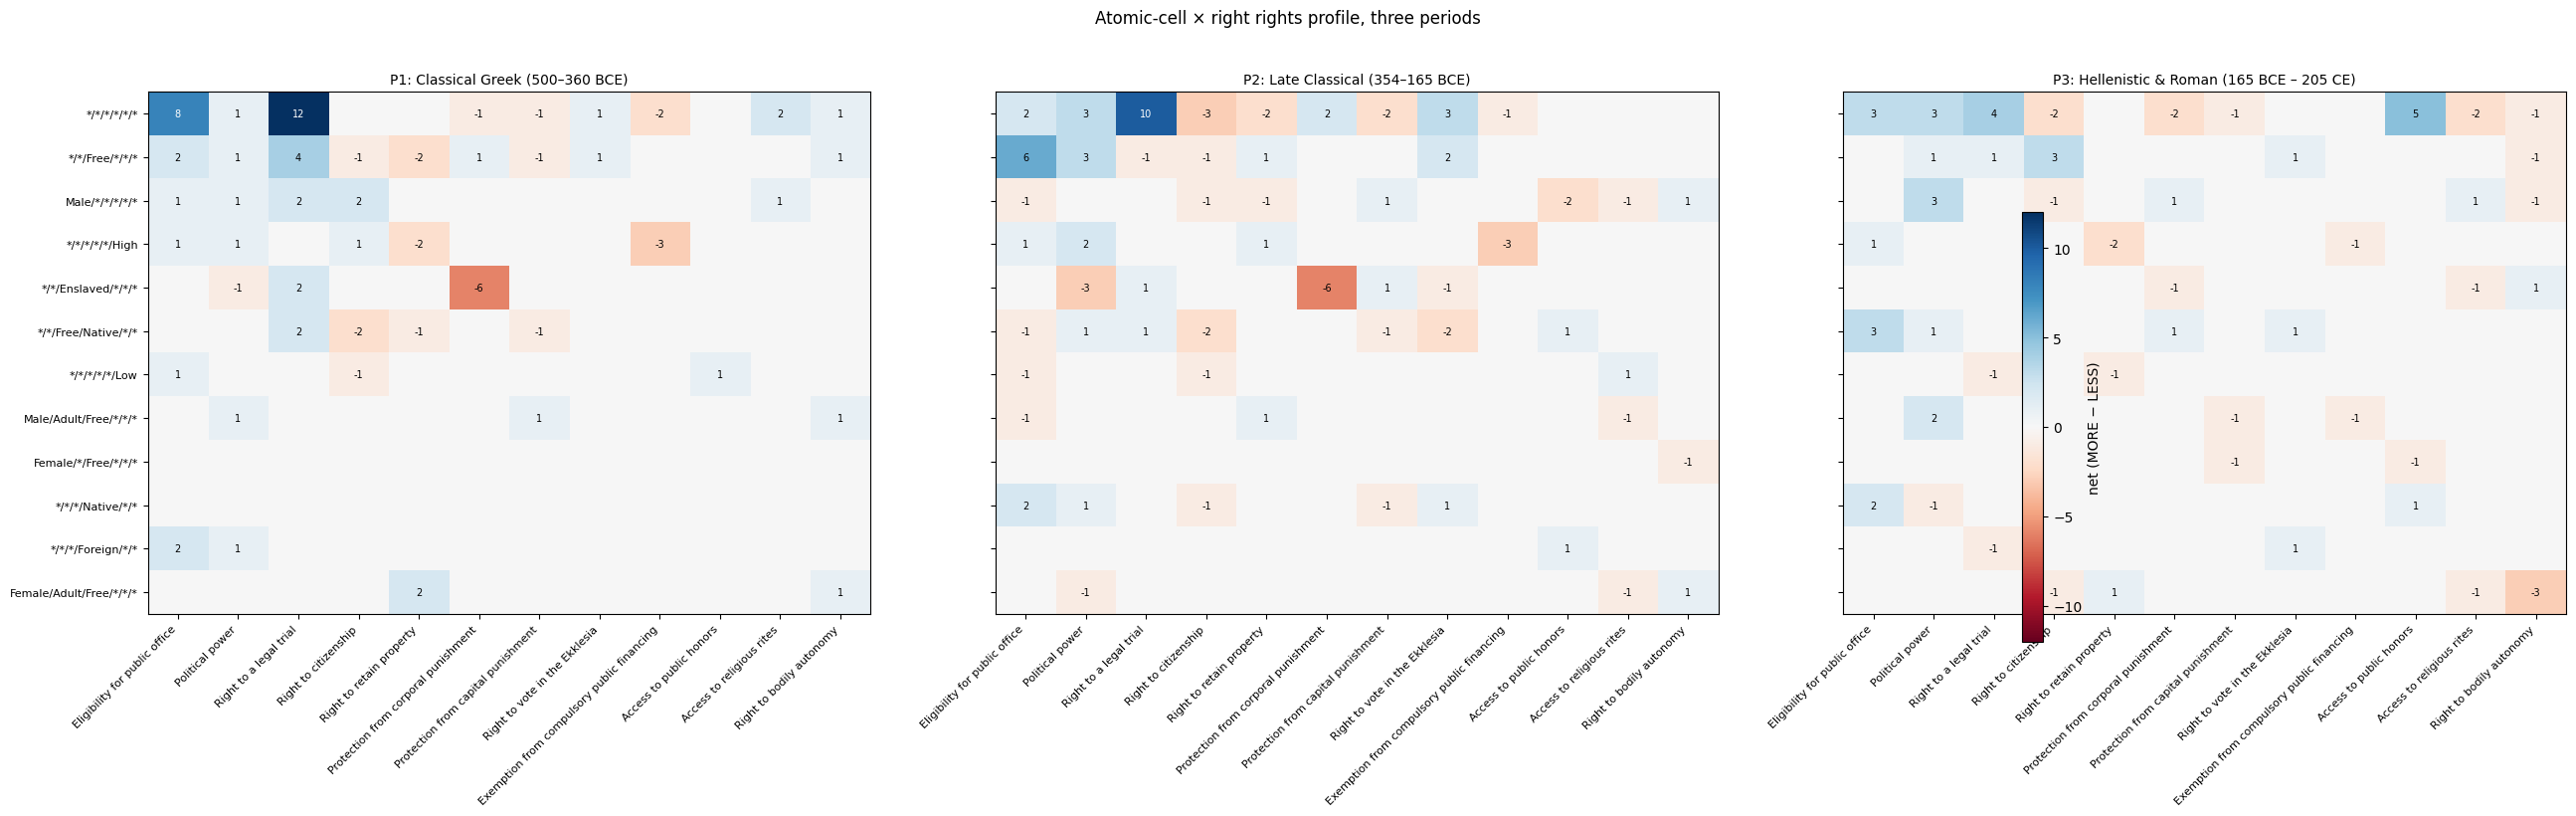

In [12]:
top_cells_all = F['cell_sig'].value_counts().head(12).index.tolist()
top_resources_all = F['resource_meta'].value_counts().head(12).index.tolist()

def heatmap_for(period: str) -> pd.DataFrame:
    s = F[F['period3'] == period]
    by = (s[s['cell_sig'].isin(top_cells_all) & s['resource_meta'].isin(top_resources_all)]
          .groupby(['cell_sig','resource_meta','directionality']).size().unstack('directionality', fill_value=0))
    for c in ('MORE','LESS'):
        if c not in by.columns:
            by[c] = 0
    by['net'] = by['MORE'] - by['LESS']
    grid = by['net'].unstack('resource_meta').reindex(index=top_cells_all, columns=top_resources_all).fillna(0)
    return grid

fig, axes = plt.subplots(1, 3, figsize=(26, 8), sharey=True)
vmax = max(abs(heatmap_for(p).values).max() for p in PERIODS)
for ax, p in zip(axes, PERIODS):
    grid = heatmap_for(p)
    im = ax.imshow(grid.values, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index, fontsize=8)
    ax.set_title(p, fontsize=10)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = int(grid.iat[i, j])
            if v != 0:
                ax.text(j, i, str(v), ha='center', va='center', fontsize=7,
                        color='white' if abs(v) > vmax*0.5 else 'black')
fig.colorbar(im, ax=axes, shrink=0.7, label='net (MORE − LESS)')
plt.suptitle('Atomic-cell × right rights profile, three periods', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 7. Worked example: the `politēs`-shaped cell across periods

Cell `M-A-F-N-R-*` = sex=male, age=adult, ownership=free, ancestry=native, residence=resident, wealth=any.
This is the cell Athenians called *politēs* (and Romans *civis*) — but the cell is defined here in rights-independent terms. Let's look at how its rights profile shifts across the three periods.

In [13]:
def cell_profile_across_periods(cell_sig: str) -> pd.DataFrame:
    pieces = []
    for p in PERIODS:
        r = rho_by_period[p]
        sub = (r[r['cell_sig'] == cell_sig]
               .groupby('resource_meta')[['MORE','LESS','net']].sum()
               .rename(columns={'MORE': f'{p}|MORE', 'LESS': f'{p}|LESS', 'net': f'{p}|net'}))
        pieces.append(sub)
    m = pd.concat(pieces, axis=1).fillna(0).astype(int)
    m['total_n'] = m.filter(like='|MORE').sum(axis=1) + m.filter(like='|LESS').sum(axis=1)
    return m.sort_values('total_n', ascending=False).drop(columns='total_n')

TARGET = 'Male/Adult/Free/Native/Resident/*'
print(f'Rights profile of cell {TARGET}')
print('(male, adult, free, native, resident, any wealth — the politēs / civis cell)')
print()
cell_profile_across_periods(TARGET).head(20)

Rights profile of cell Male/Adult/Free/Native/Resident/*
(male, adult, free, native, resident, any wealth — the politēs / civis cell)



,P1: Classical Greek (500–360 BCE)|MORE,P1: Classical Greek (500–360 BCE)|LESS,P1: Classical Greek (500–360 BCE)|net,P2: Late Classical (354–165 BCE)|MORE,P2: Late Classical (354–165 BCE)|LESS,P2: Late Classical (354–165 BCE)|net,P3: Hellenistic & Roman (165 BCE – 205 CE)|MORE,P3: Hellenistic & Roman (165 BCE – 205 CE)|LESS,P3: Hellenistic & Roman (165 BCE – 205 CE)|net
resource_meta,,,,,,,,,
Eligibility for public office,0,0,0,1,0,1,0,0,0


In [14]:
TARGET = '*/*/Enslaved/*/Resident/Low'
print(f'Rights profile of cell {TARGET}')
print('(enslaved, resident, low wealth, any sex/age/ancestry — the doulos cell)')
print()
cell_profile_across_periods(TARGET).head(20)

Rights profile of cell */*/Enslaved/*/Resident/Low
(enslaved, resident, low wealth, any sex/age/ancestry — the doulos cell)



,P1: Classical Greek (500–360 BCE)|MORE,P1: Classical Greek (500–360 BCE)|LESS,P1: Classical Greek (500–360 BCE)|net,P2: Late Classical (354–165 BCE)|MORE,P2: Late Classical (354–165 BCE)|LESS,P2: Late Classical (354–165 BCE)|net,P3: Hellenistic & Roman (165 BCE – 205 CE)|MORE,P3: Hellenistic & Roman (165 BCE – 205 CE)|LESS,P3: Hellenistic & Roman (165 BCE – 205 CE)|net
resource_meta,,,,,,,,,


## 8. Diagnostic — where text-grounded and label-grounded disagree

Per-axis agreement between the two pipelines, computed on the same rule set. The text-grounded vectors come from `rule_criterion_vectors.tsv` (read the verbatim, mark each axis `stated` / `implied` / `unspecified`). The label-grounded vectors come from `group_criterion_vectors.tsv` (classify the group label using background knowledge of the polity). Agreement is low precisely where background knowledge was doing the work — typically on `c_sex` and `c_age` for the *politēs* cell.

In [15]:
LABEL_SRC = ROOT / 'data/clean/final/group_criterion_vectors.tsv'
gcv = pd.read_csv(LABEL_SRC, sep='\t')
# Merge label-grounded vector onto each rule via (group, rule_polity)
lab = (df[['rule_id','group','rule_polity']]
       .merge(gcv, on=['group','rule_polity'], how='left',
              suffixes=('', '_lab')))
both = (df[['rule_id'] + AXES]
        .rename(columns={a: f'{a}_text' for a in AXES})
        .merge(lab.rename(columns={a: f'{a}_lab' for a in AXES}),
               on='rule_id', how='left'))

rows = []
for ax in AXES:
    text = both[f'{ax}_text']
    lab  = both[f'{ax}_lab']
    text_constrained = ~text.isin(['unspecified','any']) & text.notna()
    lab_constrained  = ~lab.isin(['unspecified','any']) & lab.notna()
    both_constrained = text_constrained & lab_constrained
    agree = (text == lab) & both_constrained
    disagree = (text != lab) & both_constrained
    text_says_more = lab_constrained & ~text_constrained
    text_says_less = text_constrained & ~lab_constrained
    rows.append({
        'axis': ax,
        'both_constrained': int(both_constrained.sum()),
        'agree_when_both': int(agree.sum()),
        'disagree_when_both': int(disagree.sum()),
        'label_only (background-knowledge filled)': int(text_says_more.sum()),
        'text_only (label classifier missed)':    int(text_says_less.sum()),
    })
disagree_df = pd.DataFrame(rows)
disagree_df['agree_rate_when_both'] = (disagree_df['agree_when_both'] /
                                       disagree_df['both_constrained'].replace(0,1)).round(2)
disagree_df

,axis,both_constrained,agree_when_both,disagree_when_both,label_only (background-knowledge filled),text_only (label classifier missed),agree_rate_when_both
0,c_sex,208,204,4,327,80,0.98
1,c_age,116,100,16,543,46,0.86
2,c_ownership_status,346,340,6,538,41,0.98
3,c_ancestry,161,138,23,455,16,0.86
4,c_residence,91,85,6,787,6,0.93
5,c_wealth,157,140,17,207,26,0.89


In [16]:
# Background-knowledge leakage cases: label said sex=male, text leaves it unspecified.
leak_mask = (both['c_sex_lab'] == 'male') & (both['c_sex_text'] == 'unspecified')
n_leak = int(leak_mask.sum())
print(f'{n_leak} rules where label said c_sex=male but text grounded leaves it unspecified.')

# Look up verbatim by rule_id
leak_rids = both.loc[leak_mask, 'rule_id'].head(10).tolist()
leak_view = (df.set_index('rule_id').loc[leak_rids][['group','rule_polity','rule']]
             .reset_index())
print('\nFirst 10 leakage cases:')
leak_view

323 rules where label said c_sex=male but text grounded leaves it unspecified.

First 10 leakage cases:


,rule_id,group,rule_polity,rule
0,tlg0007.tlg118.perseus-eng3::1,Citizens of Greek city-states,Roman Empire,City-state local self-government
1,tlg0007.tlg118.perseus-eng3::5,Citizens,Roman Empire,Proconsular annulment of local power
2,tlg0007.tlg119.perseus-eng3::2,Nobles,Classical Sparta,Oligarchic equal power sharing
3,tlg0014.tlg059.perseus-eng2::0,Citizens,Classical Athens,Citizen right to propose legislation
4,tlg0014.tlg059.perseus-eng2::11,Naturalized citizens,Classical Athens,Restricted office for new citizens
5,tlg0032.tlg015.perseus-eng1::14,Choragi and Trierarchs,Classical Athens,Liturgical adjudication requirements
6,tlg0032.tlg015.perseus-eng1::15,Citizens,Classical Athens,Loss of civil rights for misconduct
7,tlg0059.tlg008.perseus-eng2::8,Statesmen,Classical Greece,Statesman education and breeding standards
8,tlg0059.tlg008.perseus-eng2::17,Citizens,Classical Greece,Mandatory adherence to written laws
9,tlg0059.tlg008.perseus-eng2::23,Citizens,Classical Athens,Public participation in lawmaking


## 9. Persist outputs

In [17]:
OUT_DIR = ROOT / 'data/clean/final'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Combined rho across periods
rho_long = pd.concat(
    [rho_by_period[p].assign(period3=p) for p in PERIODS], ignore_index=True
)
rho_long.to_csv(OUT_DIR / 'atomic_cell_rights_3periods.tsv', sep='\t', index=False)

# Evolution table
evo.to_csv(OUT_DIR / 'atomic_cell_evolution_3periods.tsv', sep='\t', index=False)

# Intersectional table
intersect_long = pd.concat(
    [intersect_by_period[p].assign(period3=p) for p in PERIODS], ignore_index=True
)
intersect_long.to_csv(OUT_DIR / 'atomic_cell_intersectional_3periods.tsv', sep='\t', index=False)

print('Wrote:')
for f in ('atomic_cell_rights_3periods.tsv',
          'atomic_cell_evolution_3periods.tsv',
          'atomic_cell_intersectional_3periods.tsv'):
    p = OUT_DIR / f
    print(f'  {p.relative_to(ROOT)}  ({p.stat().st_size:,} bytes)')

Wrote:
  data/clean/final/atomic_cell_rights_3periods.tsv  (59,140 bytes)
  data/clean/final/atomic_cell_evolution_3periods.tsv  (27,081 bytes)
  data/clean/final/atomic_cell_intersectional_3periods.tsv  (65,522 bytes)


## Reading the notebook

- **§1** loads the text-grounded vectors and shows the period coverage. Most rules have several axes left `unspecified` — that is what the verbatim actually says.
- **§2–§3** answer: *what partition does the corpus produce, and what rights cluster on each cell?* — built from the text, not from background knowledge.
- **§4** answers: *which rights are emergent at the intersection?* — cells with `essential_axes = 6` carry rights that disappear if any single criterion is relaxed.
- **§5** answers: *which (cell, right) pairs are time-contingent?* The `+−` and `−+` trajectories are the historical changes the framework promised to make legible.
- **§6** is the side-by-side heatmap comparison.
- **§7** zooms in on the *politēs*-shaped cell and the enslaved cell across the three periods.
- **§8** is the diagnostic: how often did the old label-grounded pipeline insert criterion values that the text itself doesn't license? Read column `label_only` as 'this was background-knowledge fill-in.'

Tables saved to `data/clean/final/atomic_cell_*_3periods.tsv` for downstream plotting / paper figures.